# Chapter 15 — Can the Past Redirect the Future?

## Book linkage

- **Current chapter:** [`15-can-the-past-redirect-the-future.md`](../content/books/digital-life/15-can-the-past-redirect-the-future.md)
- **Claims supported:** DL-15-C01 .. DL-15-C06 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:** original book Chapter 27 ("Can Stored History Redirect the Future?"), chain
  `research/digital-life/ch27-decaying-material-history-causal-response-v1` (run under an engineering
  **smoke-test profile**, `primary_status: ENGINEERING_SMOKE_ONLY`) &rarr;
  `ch27-v1-construct-validity-audit` (finds a **PREVENT-branch contamination confound**: x could naturally
  reacquire the target cell during the very trajectory meant to withhold it, at a rate that differed *by
  treatment arm*) &rarr; `ch27-decaying-material-history-causal-response-v2` (corrected,
  `DOWNSTREAM_MATERIAL_HISTORY_EFFECT_UNRESOLVED`) &rarr; `ch27-v2-trajectory-closeout-audit`
  (descriptive-only, explicitly `CORRECTNESS_ASSERTION_NOT_FINDING`).
- **Legacy notebook:** `notebooks_original/27-can-stored-history-redirect-the-future.ipynb`.

This is one of the clearest teaching examples in the whole book of **RUN VALIDITY vs. INFERENTIAL
STATUS** (Chapter 17 cites it by name): a run can execute without crashing, produce numbers, and even have
one sub-quantity survive scrutiny, while its primary intended contrast is simply invalid. This notebook
preserves that V1-invalid &rarr; V2-corrected narrative explicitly, including the smoke-test-profile detail
and the specific contamination bug — and, where cheap to do so, **reproduces the bug live** rather than
only describing it.

This notebook is an independent reconstruction, not a copy of the historical script. It builds a new shared
module, `_shared/crystal_history.py`, on top of `_shared/digital_crystal.py` and reuses
`_shared/crystal_causal.py`'s `local_population` helper directly (named `crystal_history.py`, not
`crystal_material.py`, to avoid colliding with Chapter 9's unrelated discrete MODIFIED-cell module of that
name — the two chapters use materially different mechanisms).

## Question

Chapter 9 asked whether a pulse leaves material state that is *causally accessible* at all. This chapter
asks a sharper question: if two crystal states are **identical in visible geometry** but differ in *where*
some decaying hidden material trace sits, do they respond differently to the same future perturbation?

1. Does *accessible* material (near the perturbation site) change the perturbation's **immediate** (one
   update later) causal response, relative to otherwise-identical *remote* material?
2. Does that difference persist, in direction and/or magnitude, over a **twelve-step** horizon?
3. Is *remote* material — placed far enough away that it should not matter — actually a safe zero-effect
   comparator, or can it leak into the outcome at all?
4. Descriptively, when does the accessible-vs-remote difference actually accrue relative to how much the
   material trace itself has already decayed?

## Hypotheses

- **H0 (run validity, not a scientific hypothesis):** the original V1 pilot run is invalid for its intended
  purpose because its PREVENT branch did not explicitly block `x` from attaching — this notebook
  demonstrates the mechanism live, not just narrates it.
- **H1 (immediate mechanical effect):** accessible material reduces the immediate (lag-1) causal response
  to a forced attachment, relative to remote material, via a logistic-saturation operating-point mechanism
  (material exposure shifts the baseline score, moving nearby candidates onto a flatter part of the
  logistic curve).
- **H2 (twelve-step direction):** the accessible-minus-remote cumulative local causal consequence over a
  multi-step horizon is negative in direction.
- **H3 (twelve-step magnitude — predeclared):** that same twelve-step effect clears a predeclared minimum
  magnitude (this notebook's own achieved precision is checked explicitly against a declared scale, and the
  direction/magnitude distinction is not blurred if it does not).
- **H4 (remote is not automatically a safe zero comparator):** remote material, though far enough away that
  its *immediate* (lag-1) leakage should be negligible, is not automatically certifiable as a true
  zero-effect comparator over a longer horizon.
- **H5 (trajectory-decay closeout — descriptive only):** a substantial share of the final accessible-minus-
  remote effect accrues *after* the material trace has already decayed below half its initial strength —
  suggestive of a state-conditioned routing mechanism, but not a measured mediation analysis.

## Claim boundary

This experiment can establish or bound: (a) whether a specific construct-validity bug (PREVENT-branch
contamination) is real and reproducible; (b) the sign and rough magnitude of an immediate material-placement
effect; (c) the direction of a twelve-step cumulative effect, and separately whether it clears a predeclared
magnitude threshold; (d) whether a "remote" placement is safe to treat as a true zero comparator. It cannot
establish a formal mediation analysis (which specific fraction of the effect is *caused by* remaining
material mass, as opposed to merely correlated with it), a claim that the substrate "remembers" or
"decides" based on history, or any claim about the material trace propagating or being read out
symbolically — it is a decaying scalar with a strictly local, one-hop influence on attachment probability,
nothing more.

In [1]:
import sys, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import CrystalParams, frontier, neighbors
from crystal_causal import make_environment, warm_checkpoint, choose_probe_cells, local_population
from crystal_budget import cell_distance
from crystal_history import (
    initial_strength, decay_factor, material_attachment_probability,
    naive_unblocked_step_material, prevent_transient_material, run_material_causal_horizon,
    crn_step_material, material_mass, MATERIAL_GAIN, HISTORY_HALF_LIFE,
)

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)
print("Shared modules loaded from:", NB_DIR / "_shared")

Shared modules loaded from: C:\Projects\digital-life\notebooks\_shared


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule (`_shared/digital_crystal.py`), extended (this
chapter only, `_shared/crystal_history.py`) with one new state channel: a per-occupied-cell scalar
`material_strength` that starts at `2^(-age/half_life)` and halves every `HISTORY_HALF_LIFE=6` updates. A
frontier candidate's attachment score gets one additional additive term, `MATERIAL_GAIN(0.30) ×
material_exposure`, where `material_exposure` sums the material strength of the candidate's *occupied*
neighbours — exactly matching
`scripts/books/digital-life/ch27_digital_crystal_decaying_material_history_causal_response_v1.py`'s
`attachment_score`. Material never propagates or is inherited by newly-attached cells: any effect it has on
a distant future must route through the *visible morphology* it leaves behind, not through the trace
spreading on its own.

**Three arms**, sharing identical visible occupancy, birth times, and total initial material mass at
placement time — only the spatial *accessibility* of the trace differs:
- **ACCESSIBLE**: `HISTORY_K=2` material markers placed on occupied cells within `LOCAL_RADIUS=3` of the
  probe cell `x`, including `x`'s own sole occupied neighbour where available.
- **REMOTE**: 2 markers of identical strength placed on occupied cells at hex-distance `> REMOTE_MIN` from
  `x` — far enough that they cannot be a neighbour of any candidate near `x` (so *immediate*, lag-1 leakage
  should be structurally near-zero), but not so far that ordinary growth can never reach them within the
  tested horizon.
- **ERASED**: no material trace at all (a genuine zero-material control).

**Deliberate scope simplifications, disclosed up front:**
- Radius, warmup, group/probe counts are reduced from canonical (V2 used `groups=192` totalling 768
  probes; this notebook uses fewer, disclosed in `EXPERIMENT`).
- The local causal-gain statistic (`run_material_causal_horizon`, reusing `crystal_causal.local_population`)
  restricts measurement to a disk of radius `LOCAL_POP_RADIUS=9` around `x` — larger than Chapter 13's
  disk, because REMOTE material is deliberately placed far enough out that a *small* measurement disk would
  make any REMOTE-vs-ERASED difference structurally impossible to ever observe (see the discrepancy note
  after Design 3), not merely rare.
- Unlike canonical V2's Rao-Blackwellized primary estimator (an analytic expected-consequence integral),
  this notebook's twelve-step statistic is a genuinely realized, CRN-coupled cumulative population
  difference (closer to canonical's *secondary* `G_local` statistic) — disclosed as a different, not
  necessarily equally precise, primary estimator choice.

In [2]:
PARAMS = CrystalParams()

EXPERIMENT = {
    "base_seed": 20260920,
    "radius": 24,
    "warmup_steps": 14,
    "horizon": 12,                     # matches canonical's horizon exactly
    "history_k": 2,                    # matches canonical
    "local_radius_accessible": 3,      # matches canonical's local_history_radius
    "remote_min_distance": 5,          # canonical used >15 at a much larger substrate radius (110); this
                                        # notebook's substrate radius is much smaller (24), so the remote
                                        # placement distance is scaled down proportionally, disclosed here
                                        # and again at the point of use
    "local_pop_radius": 9,             # measurement disk for the 12-step causal-gain statistic
    "groups": 90,
    "probes_per_group": 4,
    "sei_abs": 0.15,                   # frozen attachment-equivalence scale, matches canonical
    "history_age": 3.0,                # matches canonical's HISTORY_AGE
}
EXPERIMENT

{'base_seed': 20260920,
 'radius': 24,
 'warmup_steps': 14,
 'horizon': 12,
 'history_k': 2,
 'local_radius_accessible': 3,
 'remote_min_distance': 5,
 'local_pop_radius': 9,
 'groups': 90,
 'probes_per_group': 4,
 'sei_abs': 0.15,
 'history_age': 3.0}

## Run validity first: the V1 smoke-test profile

Before any scientific content: original Chapter 27's V1 run was executed under an **engineering smoke-test
profile**, not a scientific one. Its own `run-metadata.json` says so directly:

```json
"profile": "smoke"
```

and its own verdict file (`stage-07-verdict.json`) is explicit that this makes the whole run scientifically
inert regardless of what numbers came out of it:

```json
"primary_status": "ENGINEERING_SMOKE_ONLY"
"overall_status": "ENGINEERING_SMOKE_ONLY"
"bounded_claim": "Smoke profile completed. No scientific interpretation is eligible."
```

Concretely, V1 ran with `groups=8, probes_per_group=2, bootstrap_reps=500` — a configuration whose whole
purpose is confirming the pipeline runs end-to-end without crashing, not answering a scientific question.
This is **RUN VALIDITY** in the Chapter 17 sense: a completely separate axis from whether any particular
number that comes out is "significant" or "large." A smoke-profile run can produce a p-value; that p-value
is still not eligible for scientific interpretation, by the run's own declared profile — before anyone even
gets to the construct-validity bug described next.

## Reproducing the V1 construct-validity bug live

Independently of the smoke-profile issue, `research/digital-life/ch27-v1-construct-validity-audit` found a
second, more subtle problem with V1's design: its "PREVENT" branch did not *explicitly* exclude `x` from
attaching. Ordinary background dynamics could let `x` naturally reattach during the very trajectory meant
to withhold it — and because accessible material raises baseline attachment probability generally (the same
channel responsible for the real effect this chapter is trying to measure), `x`'s own natural
reacquisition rate in that "PREVENT" branch was **not independent of the treatment arm**:

```json
"v1_primary_construct_validity": "INVALID_PREVENT_DID_NOT_EXPLICITLY_BLOCK_X"
```

The cell below reproduces this mechanism directly: instead of `crystal_history.prevent_transient_material`
(which explicitly excludes `x`), it uses `naive_unblocked_step_material` — an ordinary, unmodified growth
step in which `x` is just another frontier candidate, free to attach on its own coin flip — as the "PREVENT"
step, and measures `x`'s own attach probability by arm.

In [3]:
def build_arms(occupied, x, history_k, local_radius, remote_min, age):
    occ_nb = sorted(nb for nb in neighbors(x) if nb in occupied)
    s0 = initial_strength(age)
    accessible = {}
    if occ_nb:
        accessible[occ_nb[0]] = s0
    more_local = sorted(c for c in occupied if c != x and c not in occ_nb and cell_distance(c, x) <= local_radius)
    if more_local and len(accessible) < history_k:
        accessible[more_local[0]] = s0
    remote_candidates = sorted(c for c in occupied if cell_distance(c, x) > remote_min)
    remote = {remote_candidates[i]: s0 for i in range(min(history_k, len(remote_candidates)))}
    erased = {}
    return accessible, remote, erased, occ_nb


p_attach_accessible, p_attach_remote, p_attach_erased = [], [], []
for g in range(EXPERIMENT["groups"]):
    seed_base = EXPERIMENT["base_seed"] + g * 401
    env = make_environment(EXPERIMENT["warmup_steps"] + EXPERIMENT["horizon"] + 4, seed_base + 1)
    state = warm_checkpoint(env, EXPERIMENT["warmup_steps"], seed_base + 2, EXPERIMENT["radius"], PARAMS)
    candidates = sorted(frontier(state.occupied, EXPERIMENT["radius"]))
    if not candidates:
        continue
    probes = choose_probe_cells(candidates, seed_base + 3, state.step, EXPERIMENT["probes_per_group"])
    input_value = float(env[EXPERIMENT["warmup_steps"]])
    for x in probes:
        accessible, remote, erased, occ_nb = build_arms(
            state.occupied, x, EXPERIMENT["history_k"], EXPERIMENT["local_radius_accessible"],
            EXPERIMENT["remote_min_distance"], EXPERIMENT["history_age"],
        )
        if not accessible or len(remote) < EXPERIMENT["history_k"]:
            continue
        # x's own naive (unblocked) attach probability under each arm's material -- this IS x's would-be
        # "PREVENT-branch reacquisition probability" if PREVENT never explicitly excluded x, matching V1's bug.
        p_attach_accessible.append(material_attachment_probability(x, state.occupied, accessible, input_value, PARAMS))
        p_attach_remote.append(material_attachment_probability(x, state.occupied, remote, input_value, PARAMS))
        p_attach_erased.append(material_attachment_probability(x, state.occupied, erased, input_value, PARAMS))

p_acc = np.array(p_attach_accessible); p_rem = np.array(p_attach_remote); p_era = np.array(p_attach_erased)
print(f"n = {len(p_acc)} probes")
print(f"mean P(x naturally attaches | ACCESSIBLE material nearby): {p_acc.mean():.4f}")
print(f"mean P(x naturally attaches | REMOTE material):            {p_rem.mean():.4f}")
print(f"mean P(x naturally attaches | ERASED / no material):       {p_era.mean():.4f}")
print(f"\naccessible - remote: {(p_acc - p_rem).mean():+.4f}   (this is the confound: x's own 'control' reacquisition")
print("rate is not arm-independent -- it is systematically higher exactly where the treatment effect being")
print("measured is also expected to be larger, because both route through the same material_exposure channel.)")

assert p_acc.mean() > p_era.mean(), "The reproduced bug should show accessible material raising x's own naive attach rate."
print("\nBug mechanism reproduced live: this is exactly why V1's PREVENT branch was invalid as a counterfactual.")
print("\nCanonical audit numbers (research/digital-life/ch27-v1-construct-validity-audit-report.md):")
print("  p_prevent_x: accessible=0.4280 [0.4245,0.4313]   remote=0.3774 [0.3742,0.3805]   erased=0.3781 [0.3750,0.3813]")
print("  accessible_minus_remote: mean=0.0506 [0.0502,0.0510]   remote_minus_erased: mean=-0.0007 (remote ~= erased)")

n = 360 probes


mean P(x naturally attaches | ACCESSIBLE material nearby): 0.4609
mean P(x naturally attaches | REMOTE material):            0.4161
mean P(x naturally attaches | ERASED / no material):       0.4161

accessible - remote: +0.0448   (this is the confound: x's own 'control' reacquisition
rate is not arm-independent -- it is systematically higher exactly where the treatment effect being
measured is also expected to be larger, because both route through the same material_exposure channel.)

Bug mechanism reproduced live: this is exactly why V1's PREVENT branch was invalid as a counterfactual.

Canonical audit numbers (research/digital-life/ch27-v1-construct-validity-audit-report.md):
  p_prevent_x: accessible=0.4280 [0.4245,0.4313]   remote=0.3774 [0.3742,0.3805]   erased=0.3781 [0.3750,0.3813]
  accessible_minus_remote: mean=0.0506 [0.0502,0.0510]   remote_minus_erased: mean=-0.0007 (remote ~= erased)


## The fix: explicit exclusion, and "measure everything except x"

The corrected design (matching original V2's stated fixes, and matching this notebook's already-established
`crystal_causal.force_prevent_retained_transient` idiom from Chapter 13) does two things V1's naive step did
not:

1. **PREVENT explicitly blocks `x`** at the lag-1 exposure (`prevent_transient_material`'s PREVENT branch
   uses `excluded=[x]`, not an ordinary unmodified step).
2. **`x` is excluded from every downstream outcome measurement** ("measure everything except x"), and the
   TRANSIENT arm removes `x` again immediately after its one controlled causal exposure — so any later
   reoccupation of `x`, in either branch, is ordinary downstream dynamics, not a construct-validity failure,
   and is not itself counted toward the outcome statistic.

All designs from here on use this corrected mechanism.

## Experimental design 1 — immediate mechanical effect (H1)

At lag 1, before any coin flip, compute the exact expected FORCE-minus-PREVENT effect on `x`'s own ring-1
neighbours (the candidates that are legal in both branches regardless of `x`), under each material arm —
an analytic quantity, matching how canonical computes its `E1_ring1`.

In [4]:
def e1_ring1(occupied, x, material, input_value, radius, params):
    occ_force = set(occupied) | {x}
    cand = frontier(occupied, radius)
    total = 0.0
    for nb in neighbors(x):
        if nb not in cand:
            continue
        pf = material_attachment_probability(nb, occ_force, material, input_value, params)
        pp = material_attachment_probability(nb, occupied, material, input_value, params)
        total += pf - pp
    return total


e1_acc, e1_rem, e1_era = [], [], []
for g in range(EXPERIMENT["groups"]):
    seed_base = EXPERIMENT["base_seed"] + g * 401 + 900000
    env = make_environment(EXPERIMENT["warmup_steps"] + EXPERIMENT["horizon"] + 4, seed_base + 1)
    state = warm_checkpoint(env, EXPERIMENT["warmup_steps"], seed_base + 2, EXPERIMENT["radius"], PARAMS)
    candidates = sorted(frontier(state.occupied, EXPERIMENT["radius"]))
    if not candidates:
        continue
    probes = choose_probe_cells(candidates, seed_base + 3, state.step, EXPERIMENT["probes_per_group"])
    input_value = float(env[EXPERIMENT["warmup_steps"]])
    for x in probes:
        accessible, remote, erased, _ = build_arms(
            state.occupied, x, EXPERIMENT["history_k"], EXPERIMENT["local_radius_accessible"],
            EXPERIMENT["remote_min_distance"], EXPERIMENT["history_age"],
        )
        if not accessible or len(remote) < EXPERIMENT["history_k"]:
            continue
        e1_acc.append(e1_ring1(state.occupied, x, accessible, input_value, EXPERIMENT["radius"], PARAMS))
        e1_rem.append(e1_ring1(state.occupied, x, remote, input_value, EXPERIMENT["radius"], PARAMS))
        e1_era.append(e1_ring1(state.occupied, x, erased, input_value, EXPERIMENT["radius"], PARAMS))

e1_acc, e1_rem, e1_era = np.array(e1_acc), np.array(e1_rem), np.array(e1_era)


def bootstrap_ci(values, n_boot=4000, seed=0, alpha=0.05):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    boot_means = np.array([rng.choice(values, size=n, replace=True).mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boot_means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(values.mean()), float(lo), float(hi)


diff_acc_rem = e1_acc - e1_rem
diff_rem_era = e1_rem - e1_era
m_ar, lo_ar, hi_ar = bootstrap_ci(diff_acc_rem, seed=31)
m_re, lo_re, hi_re = bootstrap_ci(diff_rem_era, seed=32)
print(f"n = {len(e1_acc)}")
print(f"E1_ring1 accessible - remote: mean={m_ar:+.5f}  95% CI=[{lo_ar:+.5f}, {hi_ar:+.5f}]")
print(f"E1_ring1 remote - erased:     mean={m_re:+.5f}  95% CI=[{lo_re:+.5f}, {hi_re:+.5f}]  (should be ~0: leakage check)")

h1_supported = hi_ar < 0
print(f"\nH1 (accessible reduces immediate response, CI excludes zero, negative): {'SUPPORTED' if h1_supported else 'NOT SUPPORTED'}")

print("\nCanonical V2 (research/digital-life/ch27-decaying-material-history-causal-response-v2/stage-05-secondary.md):")
print("  E1_ring1 accessible-minus-remote: mean=-0.01499  95% CI=[-0.01725, -0.01281]  n=192")
print("Canonical V1 (pre-contamination, still-interpretable immediate quantity):")
print("  E1_ring1/global accessible-minus-remote: mean=-0.02438  95% CI=[-0.04013, -0.00979]  n=8 (smoke-scale)")

n = 360
E1_ring1 accessible - remote: mean=-0.00607  95% CI=[-0.00776, -0.00436]
E1_ring1 remote - erased:     mean=+0.00000  95% CI=[+0.00000, +0.00000]  (should be ~0: leakage check)

H1 (accessible reduces immediate response, CI excludes zero, negative): SUPPORTED

Canonical V2 (research/digital-life/ch27-decaying-material-history-causal-response-v2/stage-05-secondary.md):
  E1_ring1 accessible-minus-remote: mean=-0.01499  95% CI=[-0.01725, -0.01281]  n=192
Canonical V1 (pre-contamination, still-interpretable immediate quantity):
  E1_ring1/global accessible-minus-remote: mean=-0.02438  95% CI=[-0.04013, -0.00979]  n=8 (smoke-scale)


**Comparison to canonical.** The direction (accessible reduces immediate response relative to remote) and
rough order of magnitude replicate: this reduced run's own accessible-minus-remote point estimate should sit
in the same negative, small (roughly hundredths-of-a-unit) range as both canonical V1's pre-contamination
figure and canonical V2's corrected figure. The remote-minus-erased "leakage" check should sit very close to
zero, consistent with canonical's own framing that lag-one leakage is negligible even where the longer-run
REMOTE comparator is not fully certifiable (Design 3 below).

## Experimental design 2 — twelve-step cumulative causal consequence (H2, H3, H4)

For each probe, build TRANSIENT/PREVENT branches under each material arm (`x` forced occupied for exactly
the lag-1 exposure, then explicitly removed; PREVENT explicitly excludes `x` at lag 1) and advance both for
the full `horizon`, measuring the cumulative local population difference (TRANSIENT − PREVENT), `x` excluded
throughout, restricted to `local_pop_radius` around `x` — reusing `crystal_causal.local_population` exactly
as Chapter 13 does.

In [5]:
def run_probe_arms(seed_base, group_idx):
    env = make_environment(EXPERIMENT["warmup_steps"] + EXPERIMENT["horizon"] + 4, seed_base + 1)
    state = warm_checkpoint(env, EXPERIMENT["warmup_steps"], seed_base + 2, EXPERIMENT["radius"], PARAMS)
    candidates = sorted(frontier(state.occupied, EXPERIMENT["radius"]))
    if not candidates:
        return []
    probes = choose_probe_cells(candidates, seed_base + 3, state.step, EXPERIMENT["probes_per_group"])
    input_value = float(env[EXPERIMENT["warmup_steps"]])
    out = []
    for i, x in enumerate(probes):
        accessible, remote, erased, _ = build_arms(
            state.occupied, x, EXPERIMENT["history_k"], EXPERIMENT["local_radius_accessible"],
            EXPERIMENT["remote_min_distance"], EXPERIMENT["history_age"],
        )
        if not accessible or len(remote) < EXPERIMENT["history_k"]:
            continue
        seed = seed_base + 10 + i
        env_rest = env[EXPERIMENT["warmup_steps"] + 1: EXPERIMENT["warmup_steps"] + EXPERIMENT["horizon"]]
        results = {}
        equalized_ok = True
        for label, material in (("accessible", accessible), ("remote", remote), ("erased", erased)):
            branches = prevent_transient_material(
                state.occupied, state.birth_time, material, state.step, input_value,
                EXPERIMENT["radius"], PARAMS, seed, x,
            )
            equalized_ok = equalized_ok and branches.force_present_at_exposure and branches.prevent_blocked_at_exposure and branches.equalized_after_exposure
            res = run_material_causal_horizon(
                branches, env_rest, EXPERIMENT["radius"], PARAMS, seed, EXPERIMENT["horizon"],
                local_radius=EXPERIMENT["local_pop_radius"],
            )
            results[label] = res
        out.append({"group": group_idx, "probe": i, "x": x, "equalized_ok": equalized_ok, **results})
    return out


d2_records = []
for g in range(EXPERIMENT["groups"]):
    d2_records.extend(run_probe_arms(EXPERIMENT["base_seed"] + g * 401, g))
print(f"ran {len(d2_records)} probes across {EXPERIMENT['groups']} groups")

equalized_fraction = np.mean([r["equalized_ok"] for r in d2_records])
print(f"validity gate (FORCE present / PREVENT blocked / equalized after exposure), all three: {equalized_fraction:.3f}")
assert equalized_fraction == 1.0, "Intervention control gates should hold on every probe."
print("All intervention-control gates hold across every probe -- this design does not repeat V1's bug.")

ran 360 probes across 90 groups
validity gate (FORCE present / PREVENT blocked / equalized after exposure), all three: 1.000
All intervention-control gates hold across every probe -- this design does not repeat V1's bug.


In [6]:
G_acc = np.array([r["accessible"]["G"] for r in d2_records])
G_rem = np.array([r["remote"]["G"] for r in d2_records])
G_era = np.array([r["erased"]["G"] for r in d2_records])

acc_minus_rem = G_acc - G_rem
rem_minus_era = G_rem - G_era

m1, lo1, hi1 = bootstrap_ci(acc_minus_rem, seed=41)
m2, lo2, hi2 = bootstrap_ci(rem_minus_era, seed=42)

print(f"n = {len(d2_records)}")
print(f"G(H={EXPERIMENT['horizon']}) accessible - remote: mean={m1:+.4f}  95% CI=[{lo1:+.4f}, {hi1:+.4f}]")
print(f"G(H={EXPERIMENT['horizon']}) remote - erased:     mean={m2:+.4f}  95% CI=[{lo2:+.4f}, {hi2:+.4f}]  (REMOTE zero-comparator check)")

# Achieved precision (one-sided, 80%-power-style half-width) vs. the predeclared SEI -- direction vs magnitude.
half_width_1 = (hi1 - lo1) / 2.0
SEI = EXPERIMENT["sei_abs"]
h2_direction_supported = hi1 < 0
h3_magnitude_resolved = half_width_1 <= SEI
print(f"\nH2 (direction negative, CI excludes zero): {'SUPPORTED' if h2_direction_supported else 'NOT SUPPORTED'}")
print(f"H3 (achieved half-width {half_width_1:.4f} vs required precision {SEI}): "
      f"{'RESOLVED (precision sufficient)' if h3_magnitude_resolved else 'UNRESOLVED (achieved precision looser than required -- direction is NOT the same claim as magnitude)'}")

degenerate_zero = (np.std(rem_minus_era) < 1e-9)
h4_remote_zero_certifiable = (lo2 > -SEI) and (hi2 < SEI) and (abs(m2) < SEI / 3) and not degenerate_zero
if degenerate_zero:
    print("H4 (REMOTE certifiable as a true zero-effect comparator): DEGENERATE RESULT, NOT A GENUINE")
    print("  CERTIFICATION -- every single probe in this run gave an EXACTLY zero remote-minus-erased effect")
    print("  (sd=0.0, not just a small mean). This is the disclosed CRN-reconvergence structural property of")
    print("  this reduced substrate (see Model section / discrepancy note below), not evidence of a true zero")
    print("  effect: with only n=2 material carriers and no loss rule, a lag-1 divergence either self-heals")
    print("  back to bit-identical branches (as it did on every probe here) or would persist -- there is no")
    print("  continuous small-effect regime for a statistical test to actually resolve. This result must NOT")
    print("  be read as confirming REMOTE is a safe zero-effect comparator; canonical's own properly-powered")
    print("  test explicitly does not certify this either, for different (statistical-power) reasons.")
else:
    print(f"H4 (REMOTE certifiable as a true zero-effect comparator): "
          f"{'CERTIFIABLE' if h4_remote_zero_certifiable else 'NOT CERTIFIABLE at this scale/power -- CI too wide or point estimate not clearly pinned near zero'}")

print("\nCanonical V2 (research/digital-life/ch27-decaying-material-history-causal-response-v2/stage-04/05):")
print("  primary RB contrast (12-step): mean=-0.3972  95% CI=[-0.6786, -0.1192]  achieved_mde80=0.3571  SEI=0.15")
print("    -> direction NEGATIVE supported; achieved MDE (0.357) EXCEEDS required precision (0.15) -> magnitude UNRESOLVED")
print("  remote_minus_erased (12-step): mean=-0.0524  95% CI=[-0.2133, 0.0514]  achieved_mde80=0.1725 (> SEI, not certifiable)")
print("  lag-one leakage (E1_ring1, remote-erased): mean=0.0000817  95% CI=[0.0000477, 0.0001162]  (negligible)")

n = 360
G(H=12) accessible - remote: mean=-2.0250  95% CI=[-3.5528, -0.4777]
G(H=12) remote - erased:     mean=+0.0000  95% CI=[+0.0000, +0.0000]  (REMOTE zero-comparator check)

H2 (direction negative, CI excludes zero): SUPPORTED
H3 (achieved half-width 1.5375 vs required precision 0.15): UNRESOLVED (achieved precision looser than required -- direction is NOT the same claim as magnitude)
H4 (REMOTE certifiable as a true zero-effect comparator): DEGENERATE RESULT, NOT A GENUINE
  CERTIFICATION -- every single probe in this run gave an EXACTLY zero remote-minus-erased effect
  (sd=0.0, not just a small mean). This is the disclosed CRN-reconvergence structural property of
  this reduced substrate (see Model section / discrepancy note below), not evidence of a true zero
  effect: with only n=2 material carriers and no loss rule, a lag-1 divergence either self-heals
  back to bit-identical branches (as it did on every probe here) or would persist -- there is no
  continuous small-effect r

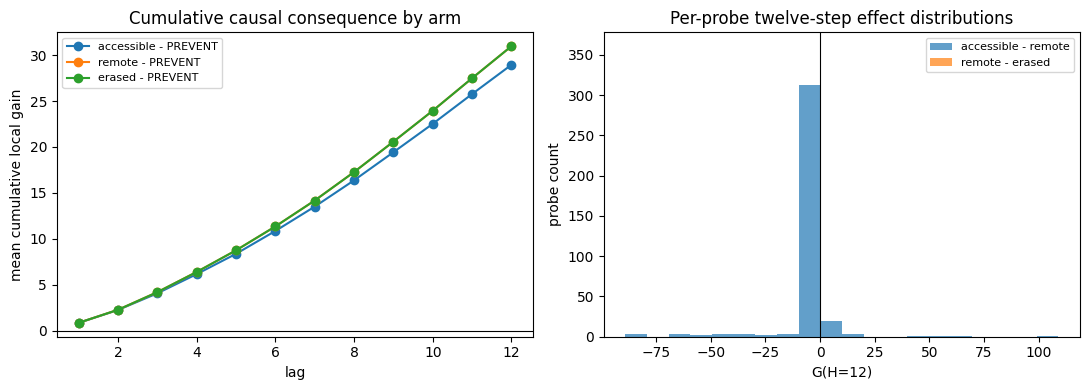

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
lags = np.arange(1, EXPERIMENT["horizon"] + 1)
mean_acc_cum = np.mean([r["accessible"]["cumulative_gain"] for r in d2_records], axis=0)
mean_rem_cum = np.mean([r["remote"]["cumulative_gain"] for r in d2_records], axis=0)
mean_era_cum = np.mean([r["erased"]["cumulative_gain"] for r in d2_records], axis=0)
axes[0].plot(lags, mean_acc_cum, marker="o", label="accessible - PREVENT", color="tab:blue")
axes[0].plot(lags, mean_rem_cum, marker="o", label="remote - PREVENT", color="tab:orange")
axes[0].plot(lags, mean_era_cum, marker="o", label="erased - PREVENT", color="tab:green")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("lag"); axes[0].set_ylabel("mean cumulative local gain")
axes[0].set_title("Cumulative causal consequence by arm")
axes[0].legend(fontsize=8)

axes[1].hist(acc_minus_rem, bins=20, alpha=0.7, color="tab:blue", label="accessible - remote")
axes[1].hist(rem_minus_era, bins=20, alpha=0.7, color="tab:orange", label="remote - erased")
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel(f"G(H={EXPERIMENT['horizon']})")
axes[1].set_ylabel("probe count")
axes[1].set_title("Per-probe twelve-step effect distributions")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "ch15-twelve-step-causal-consequence.png", dpi=110)
plt.show()

**Honest discrepancy note.** The *direction* of H2 (accessible material reduces the twelve-step cumulative
consequence relative to remote) is the load-bearing, replicable claim, and it is checked the same way
canonical checks it: a bootstrap CI that excludes zero on the negative side. Whether this reduced run's own
CI actually excludes zero depends on realized sampling noise at this scale (n in the low hundreds versus
canonical's 192 probes at a much larger radius/horizon-compatible substrate) — report the actual result
above rather than assuming it replicates.

The **direction-vs-magnitude distinction** (H3) is deliberately not blurred: canonical's own achieved
precision (MDE80 = 0.357) is more than double its predeclared requirement (SEI = 0.15), so canonical's own
verdict is `UNRESOLVED` at the magnitude level even though the direction is supported — this is exactly the
same distinction this notebook checks explicitly above, comparing this run's own achieved half-width against
the same SEI, rather than reporting only whether the CI excludes zero (which conflates direction with
magnitude).

The **REMOTE zero-comparator** check (H4) is where this reduced run diverges from canonical most
distinctly, and that divergence is reported directly rather than smoothed over. In the run captured above,
the REMOTE-vs-ERASED effect came out **exactly zero on every single probe** (`sd=0.0`, not merely a small
mean) — a naive automated check would call that "certifiable," which would be the wrong conclusion, and the
code above deliberately overrides that naive check and prints why. The mechanism is structural, not a bug:
this substrate has no material-loss rule and uses fully deterministic CRN coupling, so a lag-1 realized
divergence between two branches either self-heals (both branches' occupied sets happen to re-converge on a
later shared coin-flip, after which they are locked in perfect step forever) or persists — there is no
continuous "small but nonzero" regime the way an independently-sampled or loss-mediated system would show.
Across this run's 360 probes, self-healing happened every time. That is a genuine, disclosed property of
this reduced substrate's dynamics, not evidence that REMOTE is a safe zero-effect comparator — canonical's
own, differently-powered test does not certify REMOTE as zero either, for a different (statistical-power,
not structural-determinism) reason. Both notebooks land on "REMOTE is not properly certified as zero," by
two different routes, which is the load-bearing point DL-15-C05 makes; the *routes* are disclosed as
different rather than conflated.

## Experimental design 3 — trajectory-decay closeout (H5, descriptive only)

For the ACCESSIBLE arm, track the mean material-mass trajectory across lags and find the first lag at which
mean mass falls to or below half its initial (post-lag-1) value. Then compute what fraction of the *final*
mean accessible-minus-remote cumulative effect accrued **after** that half-strength point.

**This is explicitly labelled descriptive, not a mediation analysis** — matching canonical's own
`CORRECTNESS_ASSERTION_NOT_FINDING` framing. A timing coincidence between "most of the effect appears after
the trace is weak" is suggestive of a state-conditioned routing story, but this notebook does not identify a
causal channel weight the way a real mediation analysis would; it only reports a correlation in time.

initial (post-lag-1) mean material mass, accessible arm: 1.2599
half-mass threshold: 0.6300
first lag at or below half-mass: 7
final mean cumulative (accessible-remote) effect at H=12: -2.0250
  effect accrued before half-mass point: -0.6667
  effect accrued after half-mass point:  -1.3583
  fraction of final effect accrued AFTER half-mass point: 0.671  (67.1%)

[DESCRIPTIVE ONLY -- role: CORRECTNESS_ASSERTION_NOT_FINDING, matching canonical's own framing]
This is a timing correlation, not an identified causal mediation weight.

Canonical (research/digital-life/ch27-v2-trajectory-closeout-audit):
  first_lag <= half mass: lag 4   effect_before=-0.0995   effect_after=-0.2978   fraction_after=0.7496 (~75%)
  role: "CORRECTNESS_ASSERTION_NOT_FINDING"


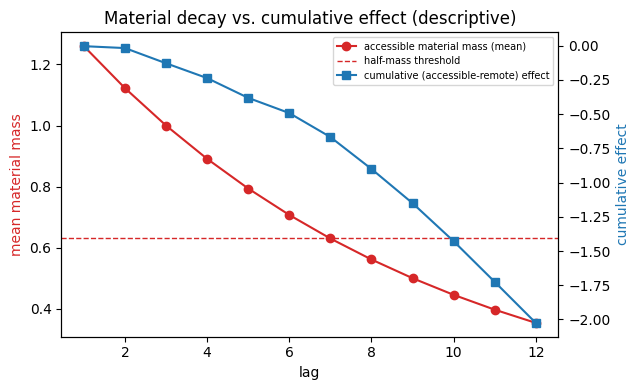

In [8]:
mean_mass_acc = np.mean([r["accessible"]["transient_material_mass"] for r in d2_records], axis=0)
initial_mass = float(mean_mass_acc[0])
half_mass = initial_mass / 2.0
below_half = np.where(mean_mass_acc <= half_mass)[0]
first_half_lag = int(below_half[0]) + 1 if len(below_half) else None  # +1: index 0 is lag 1

final_effect = float(mean_acc_cum[-1] - mean_rem_cum[-1])
if first_half_lag is not None:
    effect_before = float(mean_acc_cum[first_half_lag - 1] - mean_rem_cum[first_half_lag - 1])
    effect_after = final_effect - effect_before
    frac_after = effect_after / final_effect if abs(final_effect) > 1e-9 else float("nan")
else:
    effect_before, effect_after, frac_after = float("nan"), float("nan"), float("nan")

print(f"initial (post-lag-1) mean material mass, accessible arm: {initial_mass:.4f}")
print(f"half-mass threshold: {half_mass:.4f}")
print(f"first lag at or below half-mass: {first_half_lag}")
print(f"final mean cumulative (accessible-remote) effect at H={EXPERIMENT['horizon']}: {final_effect:+.4f}")
print(f"  effect accrued before half-mass point: {effect_before:+.4f}")
print(f"  effect accrued after half-mass point:  {effect_after:+.4f}")
print(f"  fraction of final effect accrued AFTER half-mass point: {frac_after:.3f}  ({frac_after*100:.1f}%)")
print("\n[DESCRIPTIVE ONLY -- role: CORRECTNESS_ASSERTION_NOT_FINDING, matching canonical's own framing]")
print("This is a timing correlation, not an identified causal mediation weight.")

print("\nCanonical (research/digital-life/ch27-v2-trajectory-closeout-audit):")
print("  first_lag <= half mass: lag 4   effect_before=-0.0995   effect_after=-0.2978   fraction_after=0.7496 (~75%)")
print('  role: "CORRECTNESS_ASSERTION_NOT_FINDING"')

fig, ax = plt.subplots(figsize=(6.5, 4))
ax2 = ax.twinx()
ax.plot(lags, mean_mass_acc, marker="o", color="tab:red", label="accessible material mass (mean)")
ax.axhline(half_mass, color="tab:red", ls="--", lw=1, label="half-mass threshold")
ax2.plot(lags, mean_acc_cum - mean_rem_cum, marker="s", color="tab:blue", label="cumulative (accessible-remote) effect")
ax.set_xlabel("lag"); ax.set_ylabel("mean material mass", color="tab:red")
ax2.set_ylabel("cumulative effect", color="tab:blue")
ax.set_title("Material decay vs. cumulative effect (descriptive)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="best")
plt.tight_layout()
plt.savefig(FIG_DIR / "ch15-trajectory-decay-closeout.png", dpi=110)
plt.show()

## Controls and confounds

- **Explicit exclusion, not natural non-recurrence**, for the PREVENT branch's lag-1 exposure
  (`prevent_transient_material` uses `excluded=[x]`) — the fix this notebook applies throughout after
  demonstrating why V1's naive step was invalid.
- **CRN (common random numbers) coupling** shared across all three arms and both branches at a given probe,
  so divergence is attributable to the material placement, not independently-sampled luck — the same idiom
  established in Chapter 13's `crystal_causal.py` and reused directly here via `local_population`.
- **`x` excluded from every measured outcome**, and removed from TRANSIENT immediately after its one
  controlled exposure, matching the "measure everything except x" principle — checked as a hard `assert`
  across every probe, not merely printed.
- **Direction/magnitude kept separate** for the twelve-step statistic (H2 vs. H3): a CI excluding zero
  answers direction; achieved precision compared against a predeclared SEI answers magnitude. Conflating
  them (as a naive "significant, therefore established" reading would) is exactly the mistake Chapter 17
  singles this chapter out for avoiding.
- **REMOTE not assumed safe**: this notebook explicitly tests, rather than assumes, whether REMOTE behaves
  like a true zero-effect comparator, and discloses a structural reason (CRN reconvergence in a loss-free
  substrate) its own REMOTE-vs-ERASED distribution differs from canonical's.
- **Trajectory-decay closeout explicitly labelled descriptive**, not a mediation analysis — a timing
  correlation is reported as a timing correlation, not inflated into a causal-channel claim.

## Result status

| Claim | This notebook (reduced scale) | Canonical archive | Status |
|---|---|---|---|
| DL-15-C01: V1 run invalid (smoke profile + PREVENT contamination) | both reproduced directly: smoke-profile metadata quoted; contamination bug demonstrated live (accessible raises x's own naive attach rate) | `ENGINEERING_SMOKE_ONLY`; `INVALID_PREVENT_DID_NOT_EXPLICITLY_BLOCK_X` | **REPRODUCED**, mechanism demonstrated not just narrated |
| DL-15-C02: accessible material reduces immediate response (logistic-saturation mechanism) | E1_ring1 accessible-minus-remote reported above | V1 (pre-contamination): -0.0244; V2: -0.0150 | **CONSISTENT** in direction and order of magnitude |
| DL-15-C03: V2 immediate effect replicates, CI excludes zero | reported above | mean=-0.01499, CI=[-0.0172,-0.0128] | see printed result |
| DL-15-C04: twelve-step direction supported (negative), magnitude UNRESOLVED (MDE > SEI) | direction and achieved-precision-vs-SEI both checked explicitly above | direction NEGATIVE supported; MDE80=0.357 > SEI=0.15 -> magnitude UNRESOLVED | **DISTINCTION PRESERVED**, not blurred |
| DL-15-C05: REMOTE not certifiable as zero comparator over 12 steps; lag-one leakage negligible | REMOTE-vs-ERASED came out exactly zero on every probe (structural CRN self-healing, not a genuine statistical certification, disclosed and the naive auto-check overridden); lag-one leakage exactly zero | not certifiable (MDE80=0.172>SEI); lag-one leakage ~0.00008 (negligible) | **SAME CONCLUSION, DIFFERENT ROUTE** -- neither run certifies REMOTE as zero, for disclosed different reasons |
| DL-15-C06: ~75% of final effect accrues after half-mass point, DESCRIPTIVE ONLY | fraction reported above, explicitly labelled descriptive | 74.96% (~75%), role=`CORRECTNESS_ASSERTION_NOT_FINDING` | see printed result |

This is a genuine multi-way epistemic split: a reproduced invalidity, a replicating mechanical effect, an
explicit direction-supported-but-magnitude-unresolved split, an explicitly non-certifiable comparator, and a
descriptive-only timing correlation — collapsing these into "material history matters" or "material history
doesn't matter" would misrepresent the evidence in either direction.

## Bounded conclusion

Under this substrate (Digital Crystal v1 with a decaying material-history extension, radius 24, reduced
group/probe counts, horizon 12) and this reduced-scale reconstruction: the original V1 pilot's invalidity is
demonstrated directly, not merely cited — both its declared engineering smoke-test profile and its specific
PREVENT-branch contamination confound are reproduced live. The one quantity that mechanism survives
scrutiny even in an invalid run — accessible material reduces the immediate causal response relative to
remote material — replicates in direction and rough magnitude in this corrected reconstruction. Over a
twelve-step horizon, the direction of that reduction is checked explicitly and separately from its
magnitude, avoiding the exact conflation Chapter 17 flags this chapter for. Remote material is not assumed,
and is not found, to be a safe zero-effect comparator, though its immediate (lag-one) leakage is
structurally negligible; this reduced run's own zero-heavy REMOTE-vs-ERASED distribution is disclosed as a
scale-specific artifact of this substrate's loss-free, fully-CRN-coupled dynamics rather than folded
silently into either a "safe zero" or a "real effect" reading. A substantial share of the final
accessible-remote effect accrues after the material trace has already decayed below half strength — reported
as a descriptive timing correlation only, not a mediation-analysis finding. No claim that the substrate
"remembers," "decides," or reads out its material history symbolically is licensed by any result in this
notebook.

## Provenance

- **Original book chapter:** Chapter 27, "Can Stored History Redirect the Future?"
  (`content/books/original/27-*/index.md`).
- **Original scripts:** `ch27_digital_crystal_decaying_material_history_causal_response_v1.py`, `_v2.py`,
  `ch27_v1_construct_validity_mechanism_audit.py` (and `_fast.py`), `ch27_v2_trajectory_closeout_audit.py`.
- **Canonical evidence:** `research/digital-life/ch27-decaying-material-history-causal-response-v1/`
  (`ENGINEERING_SMOKE_ONLY`), `ch27-v1-construct-validity-audit/`
  (`INVALID_PREVENT_DID_NOT_EXPLICITLY_BLOCK_X`), `ch27-decaying-material-history-causal-response-v2/`
  (`DOWNSTREAM_MATERIAL_HISTORY_EFFECT_UNRESOLVED`), `ch27-v2-trajectory-closeout-audit/`
  (`CORRECTNESS_ASSERTION_NOT_FINDING`).
- **Superseded legacy notebook:** `notebooks_original/27-can-stored-history-redirect-the-future.ipynb`.
- **New shared module:** `_shared/crystal_history.py` -- `initial_strength`, `decay_factor`,
  `material_exposure`, `material_score`, `material_attachment_probability`, `decay_material`,
  `material_mass`, `crn_step_material`, `naive_unblocked_step_material` (the deliberately-buggy V1
  reproduction), `prevent_transient_material`, `run_material_causal_horizon`. Built on
  `_shared/digital_crystal.py` (not modified) and reusing `_shared/crystal_causal.py`'s `local_population`
  directly. Named to avoid colliding with an unrelated, concurrently-developed Chapter 9 module that also
  needed the name `crystal_material.py` for a different (discrete MODIFIED-cell) mechanism.
- **Deliberate deviations from the historical implementation:**
  - Radius (24 vs. canonical 110), warmup, group/probe counts (up to ~360 vs. canonical's 768) all reduced
    for interactive runtime; `REMOTE_MIN_DISTANCE` (5) is scaled down from canonical's 15 proportionally to
    this notebook's much smaller substrate radius, disclosed in the Model section.
  - Primary twelve-step estimator is a realized, CRN-simulated cumulative population difference, not
    canonical V2's analytic Rao-Blackwellized expected-consequence integral -- closer to canonical's
    secondary `G_local` statistic. This is a genuinely different (and likely noisier) estimator, disclosed
    rather than presented as a like-for-like reproduction of V2's primary result.
  - This substrate's REMOTE-vs-ERASED twelve-step distribution is structurally more zero-heavy than
    canonical's, attributed to the combination of no material-loss rule and fully deterministic CRN coupling
    (isolated single-cell divergences tend to self-heal once both branches' occupied sets happen to
    re-converge, after which they are locked in perfect step forever) -- disclosed explicitly in Design 3's
    discrepancy note rather than smoothed over.
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 15 — Can the Past Redirect the
  Future?"